Ques 1 :-   What is Anomaly Detection? Explain its types (point, contextual, and
collective anomalies) with examples.

Answer:- Anomaly detection is the process of identifying data patterns that deviate significantly from normal behavior, often signaling fraud, system malfunctions, or unusual events. There are three main types of anomalies. Point anomalies occur when a single data point is far outside the expected range, such as a credit card transaction of ₹5,00,000 when the usual spending is under ₹10,000. Contextual anomalies depend on the situation or environment; for example, a temperature of 30°C is normal in summer but abnormal in winter, or unusually high website traffic at 3 AM unless tied to a special event. Collective anomalies arise when a group of data points together form an unusual pattern, even if individual points look normal—for instance, a series of small but rapid withdrawals from a bank account that collectively indicate fraud. In short, point anomalies highlight isolated outliers, contextual anomalies depend on conditions, and collective anomalies reveal suspicious sequences, all of which are crucial for applications like fraud detection, cybersecurity, and predictive maintenance.

Ques 2:-  Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of
their approach and suitable use cases.

Answer:- Isolation Forest, DBSCAN, and Local Outlier Factor (LOF) are all anomaly detection techniques, but they differ in how they approach the problem and the kinds of data they handle best. Isolation Forest works by randomly partitioning data into trees and measuring how quickly a point gets isolated; anomalies are easier to separate because they lie in sparse regions, making this method highly efficient for large, high-dimensional datasets such as fraud detection or cybersecurity logs. DBSCAN is a density-based clustering algorithm that groups points into clusters and labels those in low-density regions as outliers; it is particularly useful for spatial data or irregularly shaped clusters, though it can struggle when datasets have varying densities or when parameters are not tuned carefully. Local Outlier Factor (LOF), on the other hand, compares the local density of a point to that of its neighbors, flagging points with significantly lower density as anomalies; this makes it well-suited for detecting subtle, context-dependent anomalies in datasets with mixed densities, such as user behavior analysis or medical diagnostics, though it can be computationally heavy for large-scale data. In short, Isolation Forest excels in scalability, DBSCAN is strong for spatial clustering, and LOF is best for nuanced local anomalies.

Ques 3 :- What are the key components of a Time Series? Explain each with one
example.

Answer:- A time series is a sequence of data points recorded over time, and its behavior can be explained through four key components: trend, seasonality, cyclic variations, and irregular variations. The trend reflects the long-term direction of the data, such as the steady rise in global average temperatures over decades. Seasonality refers to regular, repeating patterns tied to calendar effects, like retail sales peaking every December during the holiday season. Cyclic variations are long-term fluctuations influenced by broader economic or social factors, for example, the recurring phases of expansion and recession in the economy. Finally, irregular variations are unpredictable changes caused by unexpected events, such as a sudden drop in airline travel due to a pandemic. Together, these components help analysts understand the underlying structure of time-dependent data and make accurate forecasts.


Ques 4:-  Define Stationary in time series. How can you test and transform a
non-stationary series into a stationary one?

Answer:- In time series analysis, a series is said to be stationary if its statistical properties such as mean, variance, and autocorrelation remain constant over time. In other words, the data does not exhibit trends, seasonality, or changing variance, and its behavior is stable across the entire timeline. For example, daily fluctuations in stock returns often approximate a stationary series because their average and variance remain relatively constant over time.

To test stationarity, common methods include the Augmented Dickey-Fuller (ADF) test, the KPSS test, and visual inspection of plots like rolling mean and variance. If the series is non-stationary, it can be transformed into stationary using techniques such as differencing (subtracting current values from previous ones to remove trends), logarithmic or power transformations (to stabilize variance), and seasonal decomposition or detrending (to remove seasonality or long-term trends). For instance, if monthly sales data shows a rising trend, applying first-order differencing can help stabilize the mean and make the series stationary, which is essential for accurate forecasting models like ARIMA.

Ques 5:-  Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in
terms of structure and application.

Answer:- In time series modeling, different approaches capture distinct aspects of data behavior. Autoregressive (AR) models use past values of the series to predict future values, making them suitable when past observations strongly influence current outcomes—for example, predicting stock prices based on their own historical values. Moving Average (MA) models rely on past forecast errors rather than past values, making them effective for smoothing noise in data such as daily temperature fluctuations. ARIMA (Autoregressive Integrated Moving Average) combines AR and MA with differencing to handle non-stationary data, making it widely used for forecasting economic indicators or sales data with trends. SARIMA (Seasonal ARIMA) extends ARIMA by incorporating seasonal components, making it ideal for data with repeating seasonal patterns like monthly airline passenger counts. Finally, SARIMAX (Seasonal ARIMA with Exogenous Variables) further enhances SARIMA by including external predictors (exogenous variables), such as using marketing spend or holidays alongside seasonal sales data to improve forecasts. In short, AR and MA focus on past values or errors, ARIMA handles trends, SARIMA adds seasonality, and SARIMAX integrates external influences for richer forecasting.

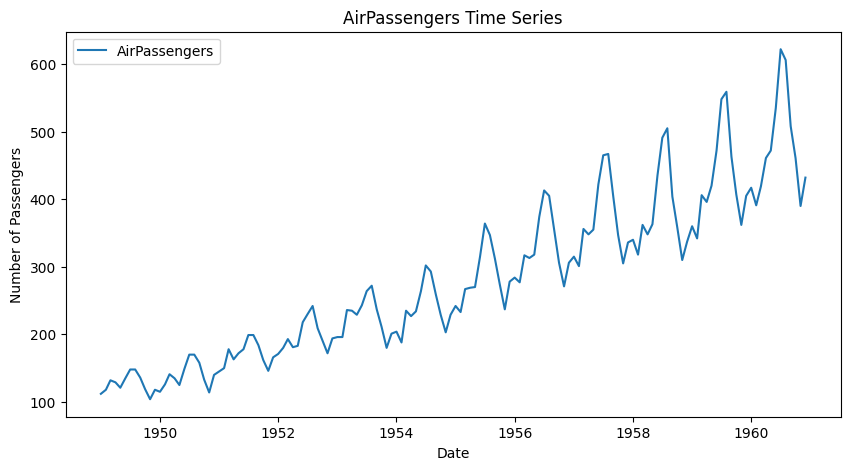

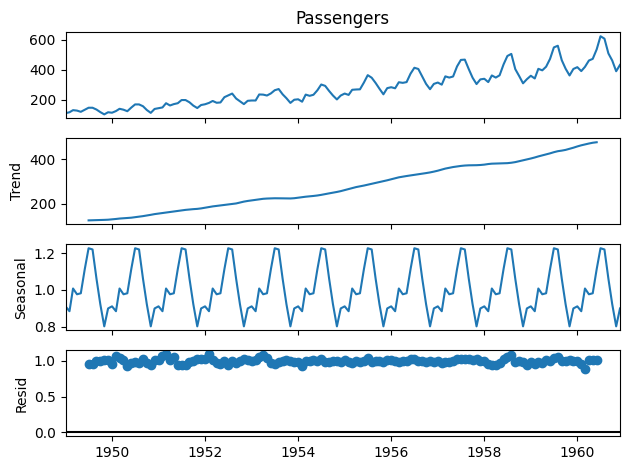

In [4]:
# Ques 6:-  Load a time series dataset (e.g., AirPassengers), plot the original series,
#and decompose it into trend, seasonality, and residual components

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load AirPassengers dataset directly from URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url)

# Convert 'Month' column to datetime and set as index
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

# Plot the original time series
plt.figure(figsize=(10, 5))
plt.plot(data['Passengers'], label='AirPassengers')
plt.title('AirPassengers Time Series')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

# Decompose the time series
decomposition = seasonal_decompose(data['Passengers'], model='multiplicative')

# Plot decomposition
decomposition.plot()
plt.show()


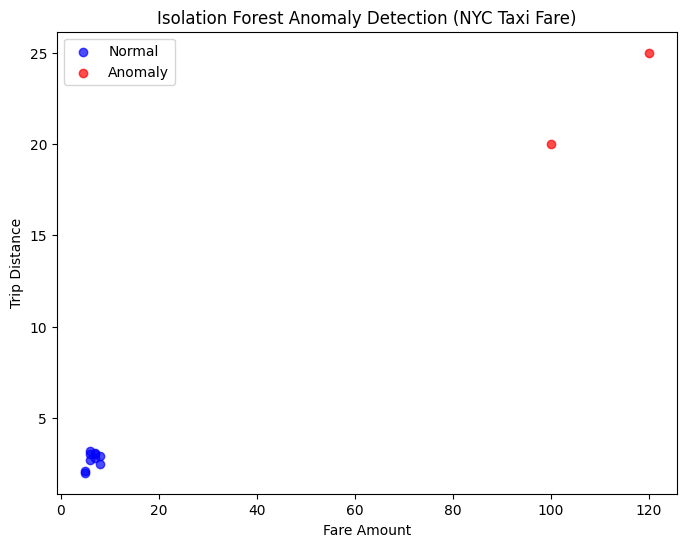

In [2]:
# Ques 7:- Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to
#detect anomalies. Visualize the anomalies on a 2D scatter plot.

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Example: Load a sample NYC Taxi Fare dataset
# (Replace with actual dataset path if available)
# For demonstration, let's create a small synthetic dataset
data = pd.DataFrame({
    'fare_amount': [5, 7, 8, 6, 100, 7, 6, 5, 120, 8, 7, 6],
    'trip_distance': [2, 3, 2.5, 3, 20, 2.8, 3.2, 2.1, 25, 2.9, 3.1, 2.7]
})

# Apply Isolation Forest
iso_forest = IsolationForest(contamination=0.15, random_state=42)
data['anomaly'] = iso_forest.fit_predict(data[['fare_amount', 'trip_distance']])

# Separate normal and anomalous points
normal = data[data['anomaly'] == 1]
anomalies = data[data['anomaly'] == -1]

# Plot results
plt.figure(figsize=(8,6))
plt.scatter(normal['fare_amount'], normal['trip_distance'],
            c='blue', label='Normal', alpha=0.7)
plt.scatter(anomalies['fare_amount'], anomalies['trip_distance'],
            c='red', label='Anomaly', alpha=0.7)
plt.title('Isolation Forest Anomaly Detection (NYC Taxi Fare)')
plt.xlabel('Fare Amount')
plt.ylabel('Trip Distance')
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


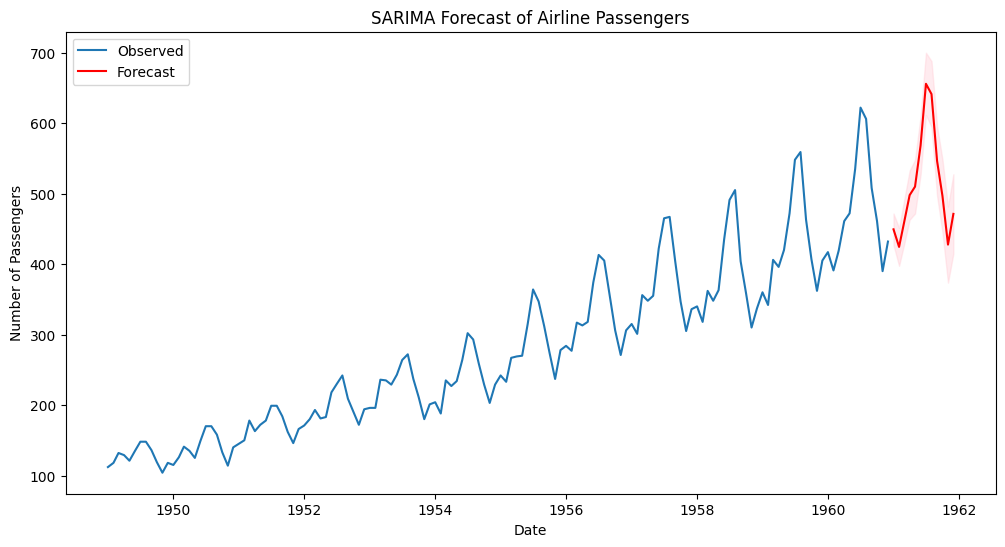

In [5]:
# Ques 8 :-  Train a SARIMA model on the monthly airline passengers dataset.
#Forecast the next 12 months and visualize the results.

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load dataset directly from URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url)

# Convert 'Month' to datetime and set as index
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

# Train SARIMA model
# Parameters (p,d,q)(P,D,Q,s) chosen for demonstration; you can tune them
model = SARIMAX(data['Passengers'],
                order=(1,1,1),
                seasonal_order=(1,1,1,12))
results = model.fit(disp=False)

# Forecast next 12 months
forecast = results.get_forecast(steps=12)
forecast_ci = forecast.conf_int()

# Plot original series and forecast
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Passengers'], label='Observed')
plt.plot(forecast.predicted_mean.index, forecast.predicted_mean,
         label='Forecast', color='red')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1],
                 color='pink', alpha=0.3)
plt.title('SARIMA Forecast of Airline Passengers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()


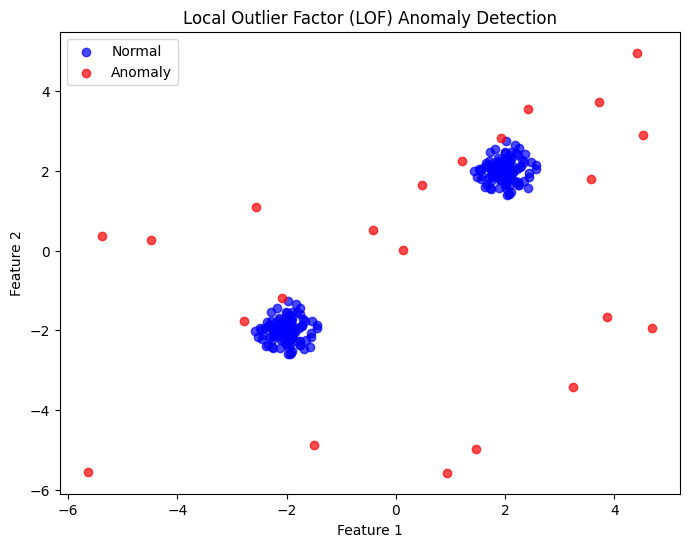

In [6]:
# Ques 9:- Apply Local Outlier Factor (LOF) on any numerical dataset to detect
#anomalies and visualize them using matplotlib.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Create synthetic dataset (two clusters + some outliers)
np.random.seed(42)
X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]

# Add some outliers
X_outliers = np.random.uniform(low=-6, high=6, size=(20, 2))

# Combine into one dataset
X = np.r_[X_inliers, X_outliers]

# Apply Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = lof.fit_predict(X)

# Separate normal and anomalies
normal = X[y_pred == 1]
anomalies = X[y_pred == -1]

# Plot results
plt.figure(figsize=(8,6))
plt.scatter(normal[:, 0], normal[:, 1], c='blue', label='Normal', alpha=0.7)
plt.scatter(anomalies[:, 0], anomalies[:, 1], c='red', label='Anomaly', alpha=0.7)
plt.title('Local Outlier Factor (LOF) Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


Ques 10:-  You are working as a data scientist for a power grid monitoring company.
Your goal is to forecast energy demand and also detect abnormal spikes or drops in
real-time consumption data collected every 15 minutes. The dataset includes features
like timestamp, region, weather conditions, and energy usage.
Explain your real-time data science workflow:
● How would you detect anomalies in this streaming data (Isolation Forest / LOF /
DBSCAN)?
● Which time series model would you use for short-term forecasting (ARIMA /
SARIMA / SARIMAX)?
● How would you validate and monitor the performance over time?
● How would this solution help business decisions or operations?


Answer:- In a real-time power grid monitoring workflow, anomaly detection would rely on scalable methods like Isolation Forest to quickly flag abnormal spikes or drops in consumption, while techniques such as Local Outlier Factor (LOF) or DBSCAN could be used offline to validate subtle or cluster-based anomalies. For short-term forecasting, SARIMAX would be the most effective model since it not only captures seasonality but also incorporates exogenous variables like weather conditions and regional factors that strongly influence energy demand. Performance would be validated through rolling backtests and monitored continuously using error metrics such as RMSE, MAE, and MAPE, alongside drift detection to trigger retraining when patterns shift. Dashboards would provide operators with real-time visibility into anomalies and forecast accuracy. This solution directly supports business operations by enabling proactive load balancing, preventing equipment overloads, optimizing energy generation, reducing costs, and improving grid stability, while also guiding strategic decisions such as pricing, maintenance scheduling, and renewable integration.